Develop an LSTM-based model for time-series forecasting using stock price, weather, or sales datasets.

In [1]:
!pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [3]:
ticker = "AAPL"

data = yf.download(
    ticker,
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True
)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.171753,24.638253,23.733994,24.627197,212818400
2015-01-05,23.490795,24.021411,23.305080,23.941819,257142000
2015-01-06,23.493017,23.751692,23.132640,23.554922,263188400
2015-01-07,23.822437,23.921927,23.590292,23.700837,160423600
2015-01-08,24.737741,24.795225,24.032464,24.149643,237458000


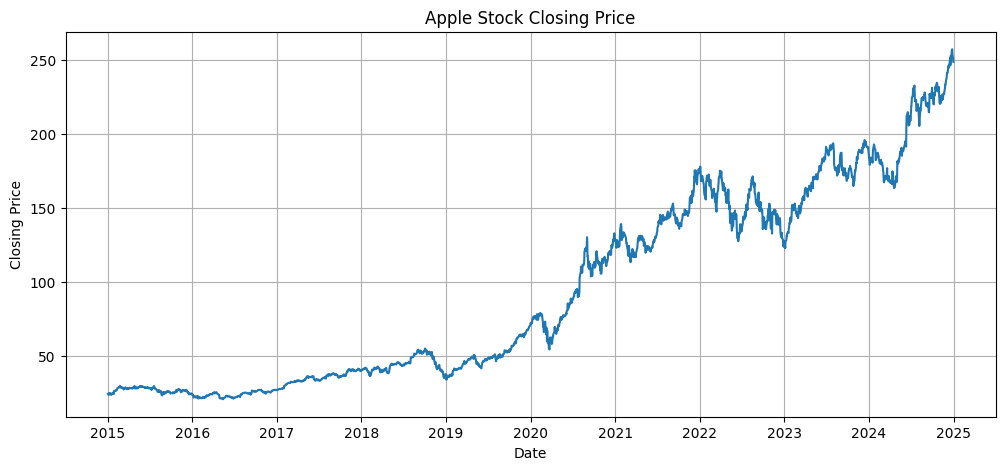

In [4]:
plt.figure(figsize=(12, 5))

plt.plot(data["Close"])

plt.title("Apple Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)

plt.show()

In [5]:
prices = data["Close"].values.reshape(-1, 1)

print("Total data points:", len(prices))

Total data points: 2516


In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(prices)

print(scaled_data[:5])

[[0.01531497]
 [0.01243695]
 [0.01244634]
 [0.01383861]
 [0.01770709]]


In [7]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2456, 60)
y shape: (2456,)


In [8]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1964
Testing samples: 492


In [9]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1964, 60, 1)
X_test shape: (492, 60, 1)


In [10]:
model = Sequential()

model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        units=50,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

model.add(Dense(25))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 0.0052 - val_loss: 0.0015
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 8.0966e-04 - val_loss: 0.0010
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 6.7185e-04 - val_loss: 7.5196e-04
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 6.4430e-04 - val_loss: 9.2426e-04
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 5.3182e-04 - val_loss: 0.0010
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 6.3871e-04 - val_loss: 0.0013
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 5.3765e-04 - val_loss: 7.0225e-04
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 5.0241e-04 - val_loss: 6.5166e-04
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 4.4266e-04 - val_loss: 6.0981e-04
Epoch 10/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 5.0487e-04 - val_loss: 0.0010
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 5.8235e-04 - val_loss: 6.2778e-04

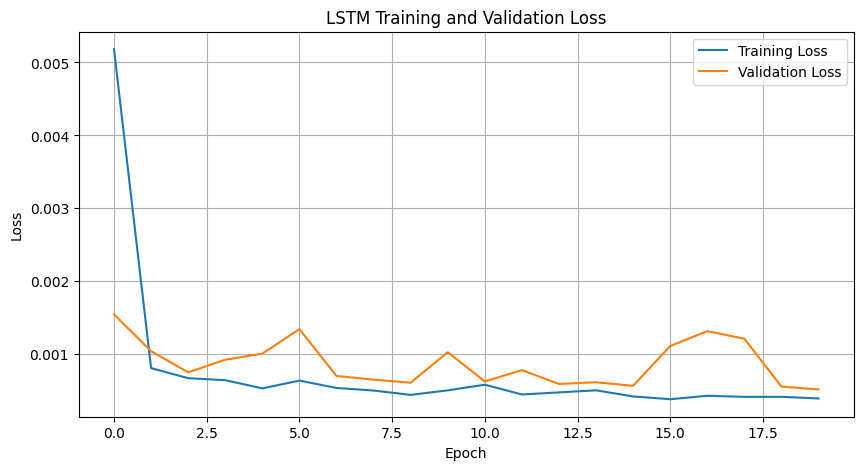

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [13]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

actual_prices = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step


In [14]:
mse = mean_squared_error(actual_prices, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_prices, predictions)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)

Mean Squared Error (MSE): 36.20190829644926
Root Mean Squared Error (RMSE): 6.01680216530752
Mean Absolute Error (MAE): 4.7382926010504


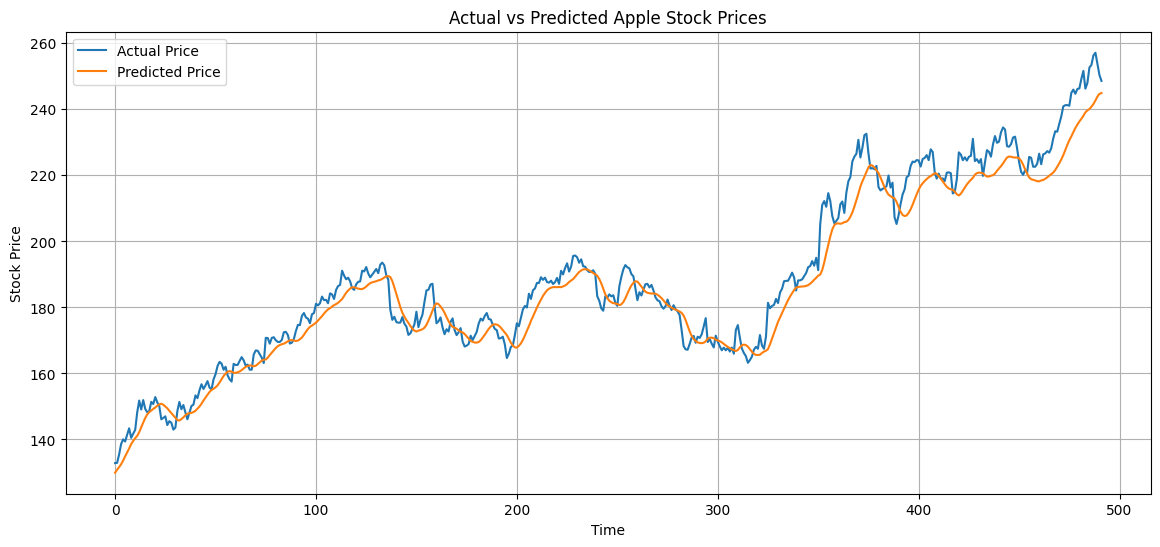

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    predictions,
    label="Predicted Price"
)

plt.title("Actual vs Predicted Apple Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()
plt.grid(True)

plt.show()

In [16]:
last_60_days = scaled_data[-60:]

X_future = last_60_days.reshape(1, 60, 1)

next_day_prediction = model.predict(X_future)

next_day_prediction = scaler.inverse_transform(
    next_day_prediction
)

print(
    "Predicted next-day closing price:",
    float(next_day_prediction[0][0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted next-day closing price: 244.6910858154297


In [17]:
results = pd.DataFrame({
    "Actual Price": actual_prices.flatten(),
    "Predicted Price": predictions.flatten()
})

results.head(10)

,Actual Price,Predicted Price
0,132.838898,129.922531
1,132.897888,130.839386
2,135.452286,131.625702
3,138.635452,132.491226
4,140.030563,133.602310
5,139.372314,134.874969
6,141.435486,136.067307
7,143.370911,137.290390
8,140.492294,138.589111
9,141.759689,139.555878
